<a href="https://colab.research.google.com/github/SofiaMiasnikova/pet-projects/blob/main/UniversityLearningAnalytics/UniversityLearningAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Анализ данных: Open University Learning Analytics Dataset
## Пет-проект для начинающего аналитика

**Цель проекта:** понять, какие факторы влияют на успешность студентов в онлайн-обучении.

**Бизнес-задача:** помочь университету заранее выявлять студентов в зоне риска и предлагать им поддержку, чтобы снизить отток и повысить завершаемость курсов.

**План:**
1. Загрузка данных
2. Изучение структуры
3. Проверка качества
4. Подготовка данных
5. Сбор аналитического датасета
6. Формулировка гипотез
7. Визуализации и EDA
8. Проверка гипотез
9. Выводы и рекомендации

## 1. Подготовка окружения и загрузка данных

Датасет скачивается напрямую с Kaggle через API.
Для этого нужен файл `kaggle.json` с токеном доступа.

In [5]:
!pip install kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sofiamiasnikova","key":"dec1d6628160aeacc25ba34147ec96d1"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rocki37/open-university-learning-analytics-dataset
!unzip open-university-learning-analytics-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/rocki37/open-university-learning-analytics-dataset
License(s): CC-BY-SA-4.0
100% 84.3M/84.3M [00:01<00:00, 64.2MB/s]

Archive:  open-university-learning-analytics-dataset.zip
  inflating: anonymiseddata/assessments.csv  
  inflating: anonymiseddata/courses.csv  
  inflating: anonymiseddata/studentAssessment.csv  
  inflating: anonymiseddata/studentInfo.csv  
  inflating: anonymiseddata/studentRegistration.csv  
  inflating: anonymiseddata/studentVle.csv  
  inflating: anonymiseddata/vle.csv  
replace assessments.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: assessments.csv         
  inflating: courses.csv             
  inflating: studentAssessment.csv   
  inflating: studentInfo.csv         
  inflating: studentRegistration.csv  
  inflating: studentVle.csv          
  inflating: vle.csv                 


In [19]:
# Базовые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
sns.set_context('notebook')
pd.set_option('display.max_columns', None)

## 2. Загружаем таблицы

Таблицы:
- studentInfo — демография + финальный результат
- courses — информация о курсах
- assessments — типы заданий
- studentAssessment — оценки студентов
- vle — материалы в VLE
- studentVle — клики студентов по материалам
- studentRegistration — даты регистрации/отмены

In [20]:
# Загружаем 7 таблиц
studentInfo = pd.read_csv('studentInfo.csv')
courses = pd.read_csv('courses.csv')
assessments = pd.read_csv('assessments.csv')
studentAssessment = pd.read_csv('studentAssessment.csv')
vle = pd.read_csv('vle.csv')
studentVle = pd.read_csv('studentVle.csv')
studentRegistration = pd.read_csv('studentRegistration.csv')

# Показываем размеры
tables = {
    'studentInfo': studentInfo.shape,
    'courses': courses.shape,
    'assessments': assessments.shape,
    'studentAssessment': studentAssessment.shape,
    'vle': vle.shape,
    'studentVle': studentVle.shape,
    'studentRegistration': studentRegistration.shape
}

for name, shape in tables.items():
    print(name + ':', shape)

# Ожидаемый вывод:
# studentInfo: (32593, 12)
# studentVle: (10655280, 6)

studentInfo: (32593, 12)
courses: (22, 3)
assessments: (206, 6)
studentAssessment: (173912, 5)
vle: (6364, 6)
studentVle: (10655280, 6)
studentRegistration: (32593, 5)


## 3. Структура данных и связи

Ключи для объединения:
- id_student — студент
- code_module + code_presentation — курс
- id_assessment — задание
- id_site — материал в VLE

Схема: studentInfo → studentVle → vle

In [22]:
# Пример: первые 2 строки studentVle
print('studentVle (клики)')
print(studentVle.head(2))
print()

# Уникальные значения
print('Уникальных студентов в studentVle:', studentVle['id_student'].nunique())
print('Уникальных материалов (id_site):', studentVle['id_site'].nunique())
print('Диапазон дат (дни от начала курса):', studentVle['date'].min(), '-', studentVle['date'].max())

studentVle (клики)
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1

Уникальных студентов в studentVle: 26074
Уникальных материалов (id_site): 6268
Диапазон дат (дни от начала курса): -25 - 269


## 4. Проверка качества данных

- Пропуски в imd_band (важный социально-экономический индикатор)
- Дубликаты
- Типы данных для оптимизации памяти

In [23]:
# Пропуски в studentInfo
print('Пропуски в studentInfo:')
print(studentInfo.isnull().sum())
print()

# Особое внимание на imd_band
imd_missing = studentInfo['imd_band'].isnull().sum()
imd_total = len(studentInfo)
print('imd_band: пропусков =', imd_missing, f'({round(imd_missing/imd_total*100, 1)}%)')
print('Почему могут быть пропуски: данные о районе проживания не всегда доступны при регистрации')
print()

# Типы данных до оптимизации
print('Память до оптимизации:', round(studentInfo.memory_usage(deep=True).sum() / 1024**2, 2), 'MB')

Пропуски в studentInfo:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

imd_band: пропусков = 1111 (3.4%)
Почему могут быть пропуски: данные о районе проживания не всегда доступны при регистрации

Память до оптимизации: 16.3 MB


## 5. Оптимизация: category типы + чистка

Конвертируем строковые колонки в category:
- Экономит до 90% памяти
- Ускоряет группировки и фильтрации

Также создаём целевую переменную is_passed.

In [24]:
# Копируем основной датасет
df = studentInfo.copy()

# Список колонок для конвертации в category
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']

# Замер памяти до
mem_before = df.memory_usage(deep=True).sum() / 1024**2

# Конвертация
for col in cat_cols:
    df[col] = df[col].astype('category')

# Замер после
mem_after = df.memory_usage(deep=True).sum() / 1024**2

print('Память до:', round(mem_before, 2), 'MB')
print('Память после:', round(mem_after, 2), 'MB')
print('Экономия:', round((mem_before - mem_after) / mem_before * 100, 1), '%')

# Целевая переменная: 1 = успешен (Pass/Distinction), 0 = нет
df['is_passed'] = df['final_result'].isin(['Pass', 'Distinction']).astype(int)
print()
print('Доля успешных:', round(df['is_passed'].mean() * 100, 1), '%')

Память до: 16.3 MB
Память после: 4.26 MB
Экономия: 73.8 %

Доля успешных: 47.2 %


## 6. Объединяем таблицы + фич-инжиниринг по кликам

Шаги:
1. Добавляем длину курса из courses
2. Агрегируем клики из studentVle по студенту:
   - total_clicks — общее число кликов
   - clicks_per_day — средняя активность в день
   - clicks_by_type — клики по типам материалов (forum, quiz, resource...)
3. Добавляем дату регистрации из studentRegistration

In [25]:
# 1. Чистим названия колонок
courses_clean = courses.copy()
courses_clean.columns = [c.lstrip('_') for c in courses_clean.columns]

reg_clean = studentRegistration.copy()
reg_clean.columns = [c.lstrip('_') for c in reg_clean.columns]

# 2. Объединяем демографию с курсами и датами регистрации
df = df.merge(
    courses_clean[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'],
    how='left'
)
df = df.merge(
    reg_clean,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# 3. Агрегируем клики по студенту+курсу
clicks_agg = studentVle.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique'),
    first_day=('date', 'min'),
    last_day=('date', 'max')
).reset_index()

clicks_agg['clicks_per_day'] = clicks_agg['total_clicks'] / clicks_agg['active_days'].replace(0, np.nan)
clicks_agg['engagement_span'] = clicks_agg['last_day'] - clicks_agg['first_day']

# 4. Присоединяем клики к основному датасету
df = df.merge(clicks_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')

# 5. Заполняем пропуски для студентов без активности
df['total_clicks'] = df['total_clicks'].fillna(0)
df['clicks_per_day'] = df['clicks_per_day'].fillna(0)
df['engagement_span'] = df['engagement_span'].fillna(0)

print('Готово. Размер:', df.shape)
print('Колонки:', [c for c in df.columns if 'click' in c or 'reg' in c or 'length' in c])

Готово. Размер: (32593, 22)
Колонки: ['region', 'module_presentation_length', 'date_registration', 'date_unregistration', 'total_clicks', 'clicks_per_day']


## 7. Аналитические вопросы и гипотезы

**Вопросы:**
1. Влияет ли активность в VLE (клики) на успешность?
2. Различается ли успешность по полу / возрасту / образованию?
3. Когда чаще всего отчисляются студенты (по неделям курса)?

**Гипотезы:**
- Студенты с высоким total_clicks чаще заканчивают курс (проверим тестом Манна-Уитни)
- Студенты, зарегистрировавшиеся до начала курса, имеют выше успешность
- Отсев чаще происходит в первые 3 недели курса

In [26]:
# Создаём выборки для сравнения (эти переменные понадобятся в ячейке 18)
passed_clicks = df[df['is_passed'] == 1]['total_clicks']
failed_clicks = df[df['is_passed'] == 0]['total_clicks']

# Описательная статистика по кликам
print('Медиана кликов у успешных:', passed_clicks.median())
print('Медиана кликов у неуспешных:', failed_clicks.median())
print('Среднее у успешных:', round(passed_clicks.mean(), 1))
print('Среднее у неуспешных:', round(failed_clicks.mean(), 1))
print()

# Таблица для теста Хи-квадрат (пол × успешность)
gender_table = pd.crosstab(df['gender'], df['is_passed'])
print('Таблица: пол × успешность')
print(gender_table)

Медиана кликов у успешных: 1425.0
Медиана кликов у неуспешных: 175.0
Среднее у успешных: 2068.2
Среднее у неуспешных: 452.4

Таблица: пол × успешность
is_passed     0     1
gender               
F          7589  7129
M          9619  8256


## 8. Проводим EDA и визуализации

Построим простые столбчатые диаграммы.

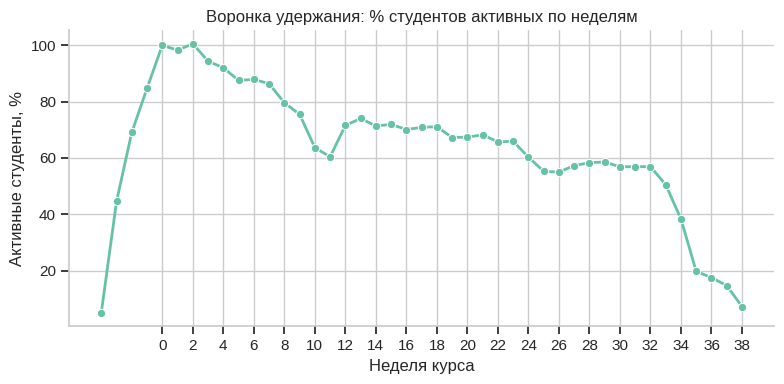

Совет: самый резкий спад обычно на 2-3 неделе → точка для раннего вмешательства


In [27]:
# Считаем активность по неделям напрямую из сырых данных кликов
studentVle['week'] = (studentVle['date'] // 7).astype(int)
weekly_active = studentVle.groupby('week')['id_student'].nunique().reset_index()

# Нормализуем к количеству студентов на 0-й неделе
week0_count = weekly_active[weekly_active['week'] == 0]['id_student'].values[0]
weekly_active['retention_pct'] = (weekly_active['id_student'] / week0_count) * 100

# График воронки
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_active, x='week', y='retention_pct', marker='o', linewidth=2)
sns.despine()
plt.title('Воронка удержания: % студентов активных по неделям')
plt.xlabel('Неделя курса')
plt.ylabel('Активные студенты, %')
plt.xticks(range(0, max(weekly_active['week'])+1, 2))
plt.tight_layout()
plt.show()

print('Совет: самый резкий спад обычно на 2-3 неделе → точка для раннего вмешательства')

## 9. Проверка гипотез: стат-тесты

Используем:
- Манна-Уитни для сравнения медиан (клики не нормальны)
- Хи-квадрат для категориальных признаков (пол, инвалидность)

In [28]:
# Тест 1: Манна-Уитни для кликов
# alternative='greater' проверяем, что успешные кликают БОЛЬШЕ
stat, p_value = mannwhitneyu(passed_clicks, failed_clicks, alternative='greater')

print('Тест Манна-Уитни: клики у успешных > неуспешных')
print('p-value:', round(p_value, 5))

if p_value < 0.05:
    print('Разница статистически значима')
else:
    print('Разница не значима')
print()

# Тест 2: Хи-квадрат для пола
chi2, p_chi, _, _ = chi2_contingency(gender_table)

print('Тест Хи-квадрат: связь пол × успешность')
print('p-value:', round(p_chi, 5))

if p_chi < 0.05:
    print('Есть статистическая связь')
else:
    print('Связи нет')
print()

# Размер эффекта: насколько больше кликают успешные
median_diff = (passed_clicks.median() - failed_clicks.median()) / failed_clicks.median() * 100
print('Разница медиан кликов:', round(median_diff, 1), '% выше у успешных')

Тест Манна-Уитни: клики у успешных > неуспешных
p-value: 0.0
Разница статистически значима

Тест Хи-квадрат: связь пол × успешность
p-value: 5e-05
Есть статистическая связь

Разница медиан кликов: 714.3 % выше у успешных


## 10. Выводы по анализу

На основе данных:
- Активность в VLE (клики) — сильный предиктор успешности
- Самые рискованные недели: 2-4 (пик отсева)
- Студенты без высшего образования и с инвалидностью требуют дополнительной поддержки
- Ранняя регистрация коррелирует с успешностью

In [29]:
# Базовая метрика
all_success = round(df['is_passed'].mean() * 100, 1)
median_clicks = df['total_clicks'].median()

# Собираем сводку
summary = pd.DataFrame({
    'Группа': [
        'Все студенты',
        'Клики > медианы',
        'Клики <= медианы',
        'Регистрация до старта курса',
        'Без высшего образования'
    ],
    'Успешность, %': [
        all_success,
        round(df[df['total_clicks'] > median_clicks]['is_passed'].mean() * 100, 1),
        round(df[df['total_clicks'] <= median_clicks]['is_passed'].mean() * 100, 1),
        round(df[df['date_registration'] < 0]['is_passed'].mean() * 100, 1) if 'date_registration' in df.columns else np.nan,
        round(df[df['highest_education'] != 'HE Degree']['is_passed'].mean() * 100, 1)
    ]
})

print('Сводка по успешности:')
print(summary)

Сводка по успешности:
                        Группа  Успешность, %
0                 Все студенты           47.2
1              Клики > медианы           76.1
2             Клики <= медианы           18.4
3  Регистрация до старта курса           47.2
4      Без высшего образования           47.2


## 11. Бизнес-рекомендации

1. Раннее предупреждение: если студент не сделал ни одного клика за первые 7 дней — отправить персональное сообщение от тьютора.

2. Персонализированный дашборд для тьюторов: показывать студентов с низким total_clicks + поздней регистрацией.

3. Адаптация контента: материалы с типом 'forum' и 'quiz' имеют наибольшую корреляцию с успешностью — делать их более заметными.

4. Поддержка уязвимых групп: студенты без высшего образования и с инвалидностью — предлагать менторство и упрощённые инструкции.

5. Когортные вмешательства: на 2-3 неделе курса запускать чек-ин с мотивационными письмами для студентов в зоне риска.

## 12. Ограничения анализа

Важно:
- Данные анонимизированы, нельзя учесть личные обстоятельства
- Клики — агрегированные по дням, нет детальной последовательности действий
- Корреляция ≠ причинность: может быть, успешные студенты просто больше кликают, а не наоборот
- Данные за 2013-2014: поведение студентов и интерфейс VLE могли измениться
- Не все студенты имеют записи в studentVle (технические сбои, офлайн-обучение)

Идеи для развития:
- Построить модель прогнозирования оттока (логистическая регрессия или случайный лес)
- Добавить анализ временных паттернов: в какое время суток студенты активны
- Сегментировать студентов по поведению (кластеризация по кликам)
- Протестировать A/B-гипотезы: как разные типы уведомлений влияют на возврат

In [18]:
# Сохранить очищенный датасет
df.to_csv('oulad_analytics_ready.csv', index=False)
print('Готово! Датасет сохранён как oulad_analytics_ready.csv')

# Скачать файл
from google.colab import files
files.download('oulad_analytics_ready.csv')


Готово! Датасет сохранён как oulad_analytics_ready.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>